In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv('train_cleaned.csv')
df.head()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,...,Response,claim_history,premium_hike_pct,months_since_last_interaction,late_payments,campaign_contacted,campaign_type,campaign_response,lapse_risk_score,renewal_status
0,1,Male,44,1,28,0,> 2 Years,Yes,40454.0,26,...,1,4,26.30,9,1,0,NaN,NaN,Medium,1
1,2,Male,76,1,3,0,1-2 Year,No,33536.0,26,...,0,0,17.22,5,2,1,renewal_discount,0.0,Medium,0
2,3,Male,47,1,28,0,> 2 Years,Yes,38294.0,26,...,1,3,8.29,4,0,1,agent_call,0.0,Medium,0
3,4,Male,21,1,11,1,< 1 Year,No,28619.0,152,...,0,0,7.00,10,0,1,email,0.0,Medium,1
4,5,Female,29,1,41,1,< 1 Year,No,27496.0,152,...,0,2,10.88,12,1,1,renewal_discount,0.0,High,0


# Chart 1 -- Lapse Rate by Age Group
What this chart shows:
Lapse rate broken down by age band. 
We want to see which age group is most likely to not renew.

In [7]:
#Prepping data for graph
df['age_group']= pd.cut(df['Age'],bins=[18,30,45,60,100],labels=['18-30', '31-45', '46-60', '60+'])
lapse_by_age = df.groupby('age_group')['renewal_status'].apply(lambda x:(1-x.mean())*100).reset_index()
lapse_by_age.columns = ['age_group', 'lapse_rate']

print(lapse_by_age)

  age_group  lapse_rate
0     18-30   30.803104
1     31-45   34.664122
2     46-60   35.636937
3       60+   35.944402


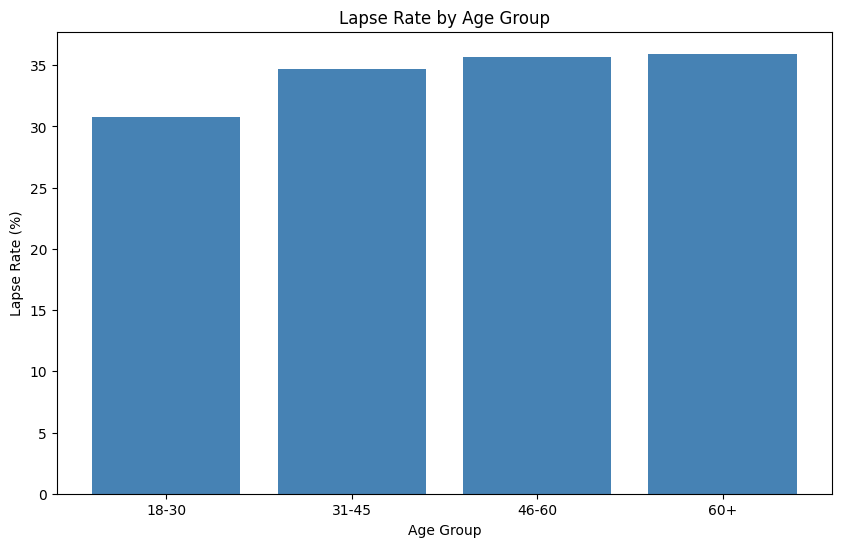

In [8]:
#plotting bar graph
plt.figure(figsize=(10,6))
plt.bar(lapse_by_age['age_group'],lapse_by_age['lapse_rate'],color='steelblue')
plt.title('Lapse Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Lapse Rate (%)')
#plt.ylim(0, 50)
plt.show()

Lapse rate increases with age, rising from 30.8% in the 18-30 group to 35.9% in the 60+ group. While the difference is not dramatic, it is consistent across every age band. Older customers are more likely to have higher claim histories and larger premium hikes, making them more susceptible to lapse. The business should prioritise retention outreach for customers aged 46 and above, particularly those who have also received significant premium increases.

# Chart 2 -- Lapse Rate by Premium Hike Band

In [9]:
df['premium_hike_band']= pd.cut(df['premium_hike_pct'],bins=[0,5,10,20,30],labels=['0-5%', '6-10%', '11-20%', '20%+'])
lapse_by_phr=df.groupby('premium_hike_band')['renewal_status'].apply(lambda x:(1-x.mean())*100).reset_index()
lapse_by_phr.columns = ['premium_hike_band','lapse_rate']
print(lapse_by_phr)

  premium_hike_band  lapse_rate
0              0-5%   19.521086
1             6-10%   25.307841
2            11-20%   36.011993
3              20%+   48.216542


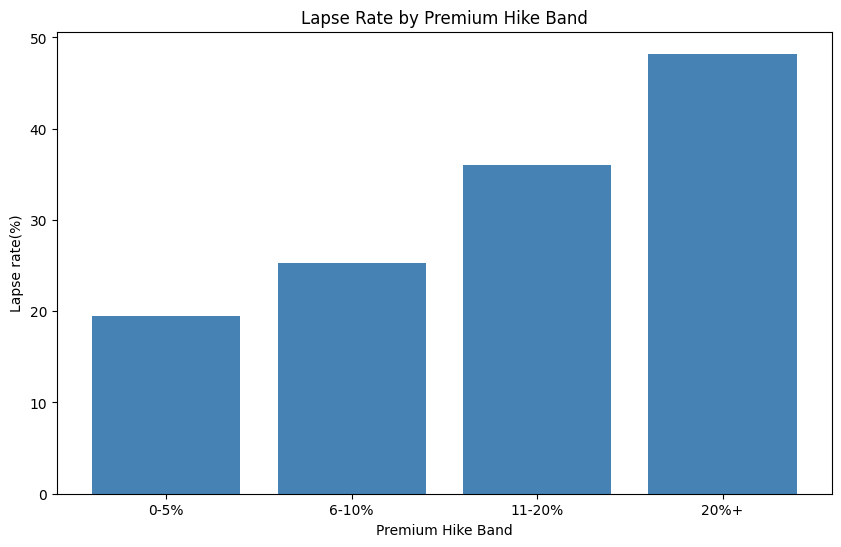

In [10]:
#plotting bar graph for Lapse Rate by Premium Hike Band
plt.figure(figsize=(10,6))
plt.bar(lapse_by_phr['premium_hike_band'],lapse_by_phr['lapse_rate'],color='steelblue')
plt.title('Lapse Rate by Premium Hike Band')
plt.xlabel('Premium Hike Band')
plt.ylabel('Lapse rate(%)')
plt.show()

Lapse rate rises sharply with premium hike size -- from 19.5% for customers 
with minimal increases to 48.2% for those facing hikes above 20%. This is the 
strongest visual signal in the dataset. The business should treat large premium 
hikes as an automatic trigger for retention intervention. Where hikes are 
unavoidable, proactive outreach -- explaining the reasons for the increase, 
offering flexible payment options, or providing a loyalty benefit -- should be 
deployed before the renewal date, not after the customer has already decided to leave.

# #Chart 3 -- Lapse Rate by Claim History

In [16]:
lapse_by_claim_history = df.groupby('claim_history')['renewal_status'].apply(lambda x:(1-x.mean())*100).reset_index()
lapse_by_claim_history.columns = ['claim_history','lapse_rate']
lapse_by_claim_history = lapse_by_claim_history[lapse_by_claim_history['claim_history'] <= 10]
print(lapse_by_claim_history)

    claim_history  lapse_rate
0               0   25.977940
1               1   30.309102
2               2   34.782840
3               3   38.293919
4               4   49.182293
5               5   51.226551
6               6   51.412429
7               7   50.962513
8               8   51.815642
9               9   52.112676
10             10   55.384615


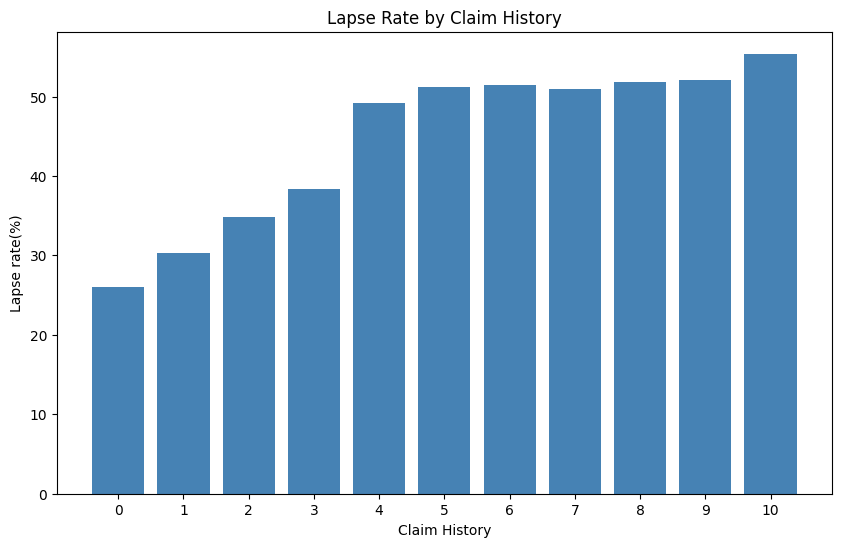

In [ ]:
#Plotting graph for Lapse Rate by Claim History
plt.figure(figsize=(10,6))
plt.bar(lapse_by_claim_history['claim_history'],lapse_by_claim_history['lapse_rate'],color='steelblue')
plt.title('Lapse Rate by Claim History')
plt.xlabel('Claim History')
plt.ylabel('Lapse rate(%)')
plt.xticks(range(0, 11)) #tells python to show all the x axis labels
plt.show()


Lapse rate rises steadily from 26% for customers with no prior claims to approximately 49% at 4 claims, where it plateaus around 51-55% for higher claim counts. The sharpest jump occurs between 3 and 4 claims -- an 11 percentage point increase -- suggesting 4 claims is a critical threshold. Customers crossing this threshold should trigger an automatic agent outreach, as agent calls have been shown to achieve the highest renewal rate of any campaign type (65.52%). Proactive communication explaining the premium impact of their claim history, combined with a personalised retention offer, gives the business the best chance of keeping these high-risk customers.


# Chart 4 -- Lapse Rate by Months Since Last Interaction

In [ ]:
#Data prep for Lapse Rate by Months Since Last Interaction graph
months_last_interaction=df.groupby('months_since_last_interaction')['renewal_status'].apply(lambda x: (1-x.mean())*100).reset_index()
months_last_interaction.columns = ['months_last_interaction','lapse_rate']
print(months_last_interaction)

    months_last_interaction  lapse_rate
0                         1   25.599350
1                         2   26.176471
2                         3   25.404968
3                         4   24.932134
4                         5   24.423623
5                         6   31.633233
6                         7   32.188339
7                         8   31.652196
8                         9   31.521260
9                        10   31.326584
10                       11   31.168426
11                       12   40.790140
12                       13   40.495809
13                       14   40.314267
14                       15   40.632037
15                       16   40.755018
16                       17   39.576146
17                       18   40.081177
18                       19   41.888620
19                       20   38.805970
20                       21   29.508197
21                       22   39.534884
22                       23   37.500000
23                       24   33.333333


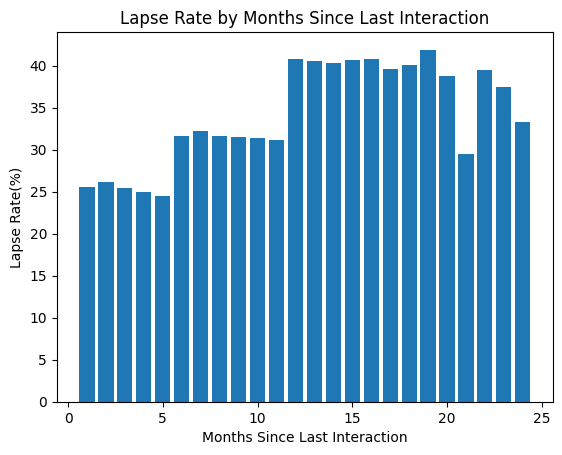

In [33]:
#Plotting graph for Lapse Rate by Months Since Last Interaction
plt.Figure(figsize=(10,6))
plt.bar(months_last_interaction['months_last_interaction'],months_last_interaction['lapse_rate'])
plt.title('Lapse Rate by Months Since Last Interaction')
plt.xlabel('Months Since Last Interaction')
plt.ylabel('Lapse Rate(%)')
plt.show()

Lapse rate shows three distinct bands based on customer engagement recency. Customers contacted within the last 5 months have a lapse rate of 24-26%. This rises to 31-32% for those last contacted 6-11 months ago, and jumps sharply to 39-41% for customers who have had no interaction for 12 months or more. The 12 month mark is a critical threshold -- at this point lapse risk increases by approximately 15 percentage points compared to recently engaged customers. The business should implement an automated engagement trigger at the 6 month mark, before customers enter the high-risk zone. Regular touchpoints -- whether a health check-in call, a policy review, or a simple email -- keep the insurer top of mind and significantly reduce the probability of silent lapse at renewal

# Now Chart 5 -- Campaign Response Rate by Campaign Type.

In [38]:

#data Prep for Campaign Response Rate by Campaign Type.
# response_by_campaign =df[df['campaign_contacted']==1].groupby('campaign_type')['campaign_response'].apply(lambda x: x.mean()*100).reset_index()
response_by_campaign.columns=['campaign_type','campaign_response_rate']
print(response_by_campaign)

      campaign_type  campaign_response_rate
0        agent_call               49.317442
1             email               19.183013
2  renewal_discount               38.700855


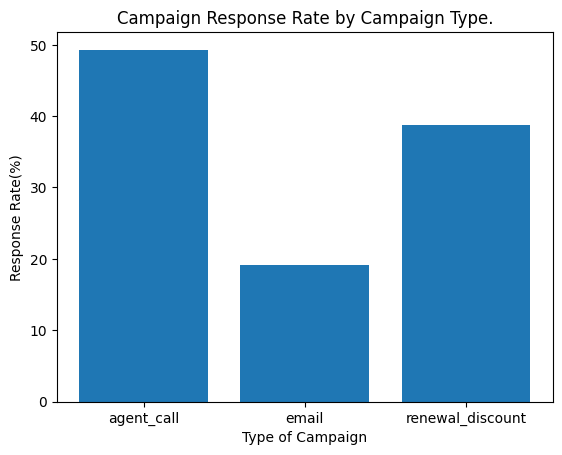

In [40]:
#Plotting graph for Campaign Response Rate by Campaign Type.
plt.Figure(figsize=(10,6))
plt.bar(response_by_campaign['campaign_type'],response_by_campaign['campaign_response_rate'])
plt.title('Campaign Response Rate by Campaign Type.')
plt.xlabel('Type of Campaign')
plt.ylabel('Response Rate(%)')
plt.show()

Agent calls achieve the highest response rate at 49.3%, more than double the email response rate of 19.2%. Renewal discounts sit in the middle at 38.7% but come at a direct cost to the business. For high risk customers -- particularly those with large premium hikes or long periods of no interaction -- agent calls should be the default outreach method. Email should be reserved for low risk customers where the cost of an agent call is not justified by the revenue at risk. Renewal discounts should be used selectively for price-sensitive customers who are likely to respond to a financial incentive but unlikely to engage with a call

# #Chart 6, Revenue at Risk Distribution.

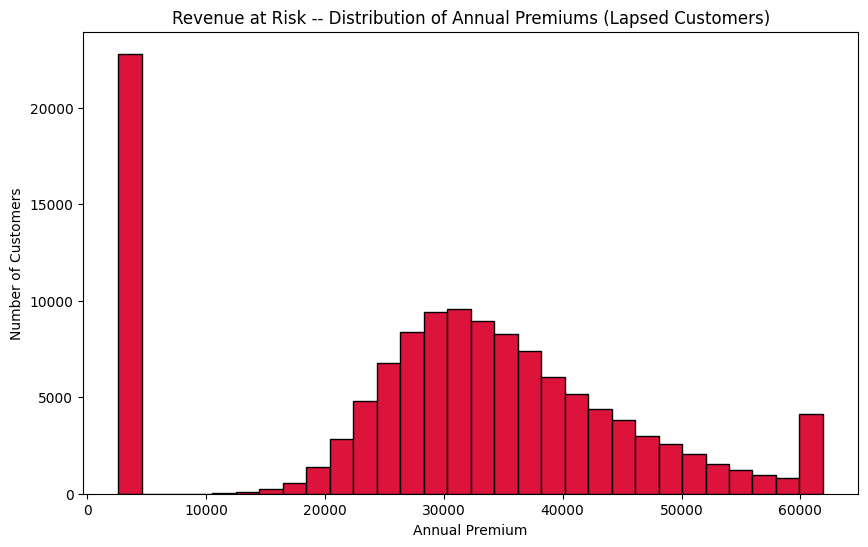

In [41]:
#Histogram to show Revenue at Risk Distribution.
lapsed = df[df['renewal_status'] == 0]

plt.figure(figsize=(10, 6))
plt.hist(lapsed['Annual_Premium'], bins=30, color='crimson', edgecolor='black')
plt.title('Revenue at Risk -- Distribution of Annual Premiums (Lapsed Customers)')
plt.xlabel('Annual Premium')
plt.ylabel('Number of Customers')
plt.show()

The majority of lapsed customers were paying annual premiums between 20,000 and 45,000, with the highest concentration around 30,000. This is where the bulk of the business's revenue loss is concentrated. The spike at the lower end and the cluster at 61,892 are artefacts of winsorising applied during data cleaning. The key business implication is that mid-tier premium customers represent the greatest volume of revenue at risk -- not the highest premium customers. A targeted agent call campaign focused on this 20,000-45,000 premium band, particularly those flagged as High or Medium risk, would recover the most revenue per retention effort. Chasing only the highest premium customers misses the majority of the problem.